# 🗺️ Procedural Terrain Generation
Using Perlin-style noise to generate elevation maps and visualize them as 3D surfaces.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

plt.style.use("dark_background")
plt.rcParams["figure.dpi"] = 120


def perlin_noise_2d(shape, scale=100, octaves=6, persistence=0.5, seed=42):
    """Generate 2D fractal noise by summing octaves of smooth random noise."""
    rng = np.random.default_rng(seed)
    noise = np.zeros(shape)
    amplitude = 1.0
    frequency = 1.0

    for _ in range(octaves):
        # Generate smooth noise at this frequency using interpolation
        grid_h = max(2, int(shape[0] / scale * frequency))
        grid_w = max(2, int(shape[1] / scale * frequency))

        # Random values at grid points
        grid = rng.standard_normal((grid_h + 1, grid_w + 1))

        # Interpolation coordinates
        y_coords = np.linspace(0, grid_h - 1, shape[0])
        x_coords = np.linspace(0, grid_w - 1, shape[1])

        # Bilinear interpolation
        y0 = np.floor(y_coords).astype(int)
        x0 = np.floor(x_coords).astype(int)
        y1 = y0 + 1
        x1 = x0 + 1

        fy = y_coords - y0
        fx = x_coords - x0

        # Smooth step (Hermite interpolation)
        fy = fy * fy * (3 - 2 * fy)
        fx = fx * fx * (3 - 2 * fx)

        # Interpolate
        for i in range(shape[0]):
            for j in range(shape[1]):
                top = grid[y0[i], x0[j]] * (1 - fx[j]) + grid[y0[i], x1[j]] * fx[j]
                bot = grid[y1[i], x0[j]] * (1 - fx[j]) + grid[y1[i], x1[j]] * fx[j]
                noise[i, j] += (top * (1 - fy[i]) + bot * fy[i]) * amplitude

        amplitude *= persistence
        frequency *= 2

    return noise


print("✓ Noise generator ready")

✓ Noise generator ready


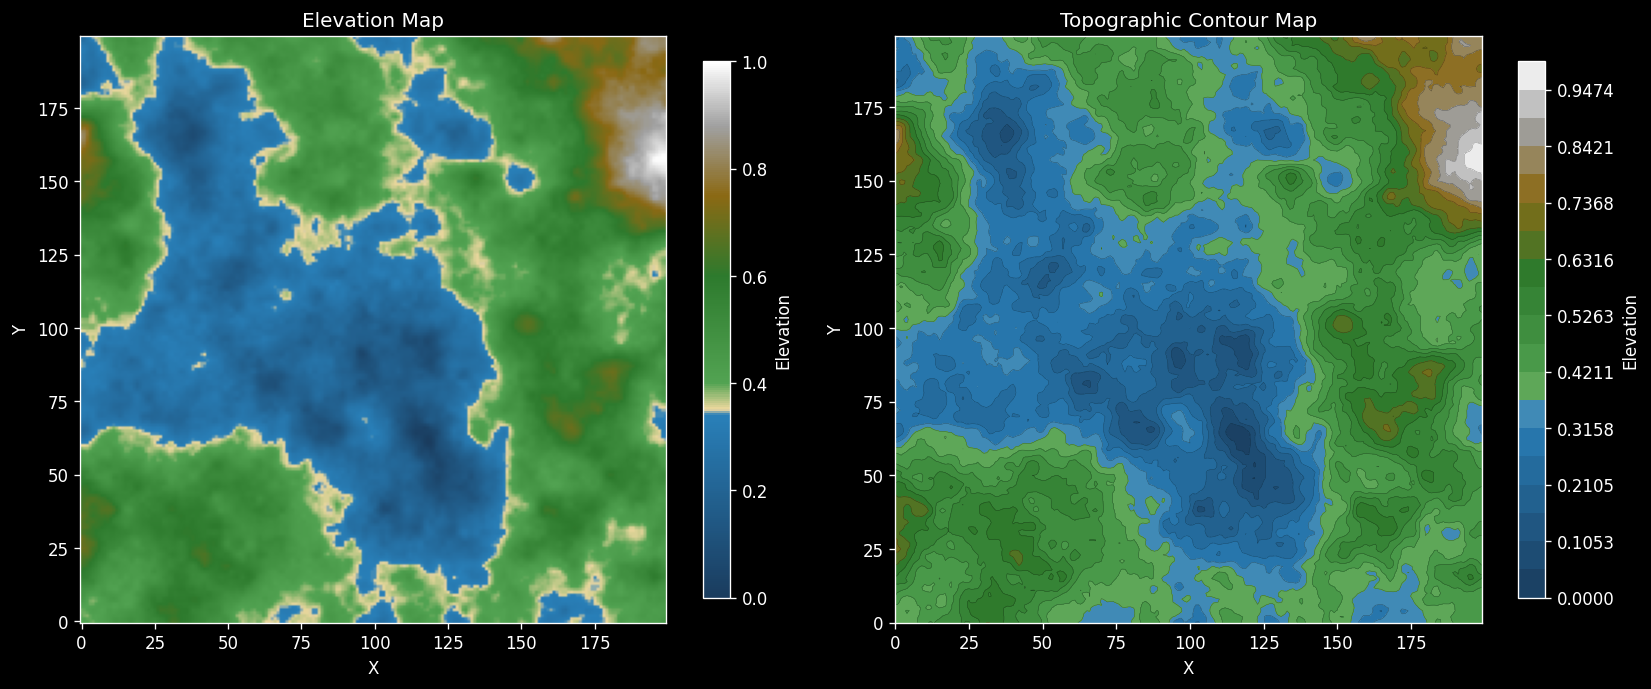

In [3]:
# Generate terrain
size = 200
terrain = perlin_noise_2d((size, size), scale=60, octaves=6, persistence=0.5, seed=7)

# Normalize to 0-1 range
terrain = (terrain - terrain.min()) / (terrain.max() - terrain.min())

# Apply sea level — anything below 0.35 is water
sea_level = 0.35
land = terrain.copy()
land[land < sea_level] = sea_level

from matplotlib.colors import LinearSegmentedColormap

# Custom terrain colormap: deep blue → sand → green → brown → snow
colors = [
    (0.00, "#1a3c5e"),  # deep water
    (0.34, "#2980b9"),  # shallow water
    (0.35, "#f0d9a0"),  # beach
    (0.40, "#52a352"),  # lowland
    (0.60, "#2d7a2d"),  # forest
    (0.75, "#8b6914"),  # highland
    (0.88, "#a0a0a0"),  # rock
    (1.00, "#ffffff"),  # snow
]
positions = [c[0] for c in colors]
hex_colors = [c[1] for c in colors]
rgb_colors = [tuple(int(h.lstrip("#")[i : i + 2], 16) / 255 for i in (0, 2, 4)) for h in hex_colors]
terrain_cmap = LinearSegmentedColormap.from_list("terrain_custom", list(zip(positions, rgb_colors)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 2D elevation map
im = axes[0].imshow(terrain, cmap=terrain_cmap, origin="lower")
axes[0].set_title("Elevation Map")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
plt.colorbar(im, ax=axes[0], label="Elevation", shrink=0.8)

# Contour map
levels = np.linspace(0, 1, 20)
cs = axes[1].contourf(terrain, levels=levels, cmap=terrain_cmap)
axes[1].contour(terrain, levels=levels, colors="black", linewidths=0.3, alpha=0.4)
axes[1].set_title("Topographic Contour Map")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].set_aspect("equal")
plt.colorbar(cs, ax=axes[1], label="Elevation", shrink=0.8)

plt.tight_layout()
plt.show()

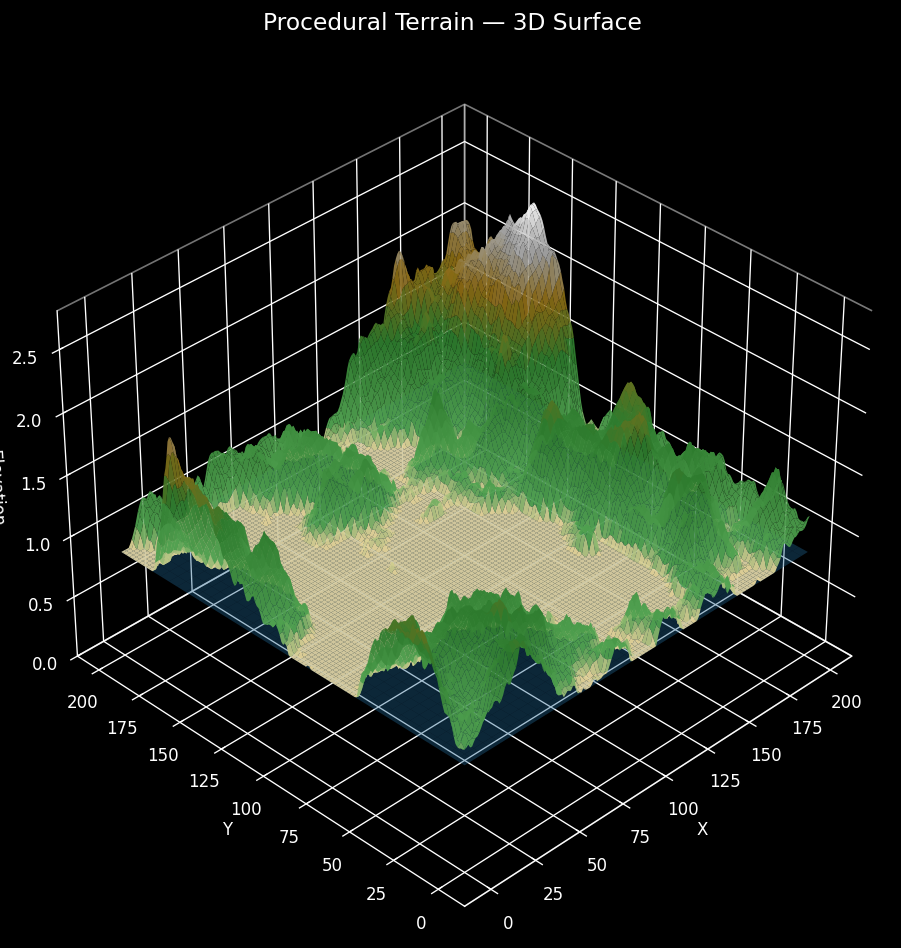

In [4]:
# 3D surface rendering
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

x = np.arange(0, size)
y = np.arange(0, size)
X, Y = np.meshgrid(x, y)

# Exaggerate elevation for visual effect
Z = land * 2.5

surf = ax.plot_surface(
    X,
    Y,
    Z,
    cmap=terrain_cmap,
    linewidth=0,
    antialiased=True,
    rstride=2,
    cstride=2,
    alpha=0.95,
    vmin=0,
    vmax=2.5,
)

# Add water plane
water = np.full_like(Z, sea_level * 2.5)
ax.plot_surface(X, Y, water, color="#2980b9", alpha=0.4, rstride=5, cstride=5)

ax.set_zlim(0, 2.8)
ax.view_init(elev=35, azim=225)
ax.set_title("Procedural Terrain — 3D Surface", fontsize=14, pad=20)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Elevation")

# Clean up axes
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

plt.tight_layout()
plt.show()